# 使用 PyTorch/TensorFlow 进行分类

来自 [AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners) 的实验任务。

## 第一部分：鸢尾花分类

鸢尾花数据集包含 150 条记录，分为 3 种不同类别的鸢尾花。每条记录包含 4 个数值参数：萼片长度/宽度和花瓣长度/宽度。这是一个简单的数据集示例，不需要使用强大的神经网络。

### 获取数据集

鸢尾花数据集内置于 Scikit Learn，因此我们可以轻松获取：


In [2]:
import matplotlib.pyplot as plt
from jedi.inference.value.instance import SelfAttributeFilter
from mpmath.identification import transforms
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
features = iris['data']
labels = iris['target']
class_names = iris['target_names']
feature_names = iris['feature_names']

print(f"Features: {feature_names}, Classes: {class_names}")

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'], Classes: ['setosa' 'versicolor' 'virginica']


### 可视化数据

在许多情况下，可视化数据是有意义的，这样可以查看数据是否看起来是可分的——这能让我们确信可以构建一个良好的分类模型。由于我们有少量的特征，可以构建一系列成对的二维散点图，用不同的点颜色表示不同的类别。这可以通过一个名为 **seaborn** 的包自动完成：


In [2]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame(features,columns=feature_names).join(pd.DataFrame(labels,columns=['Label']))

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


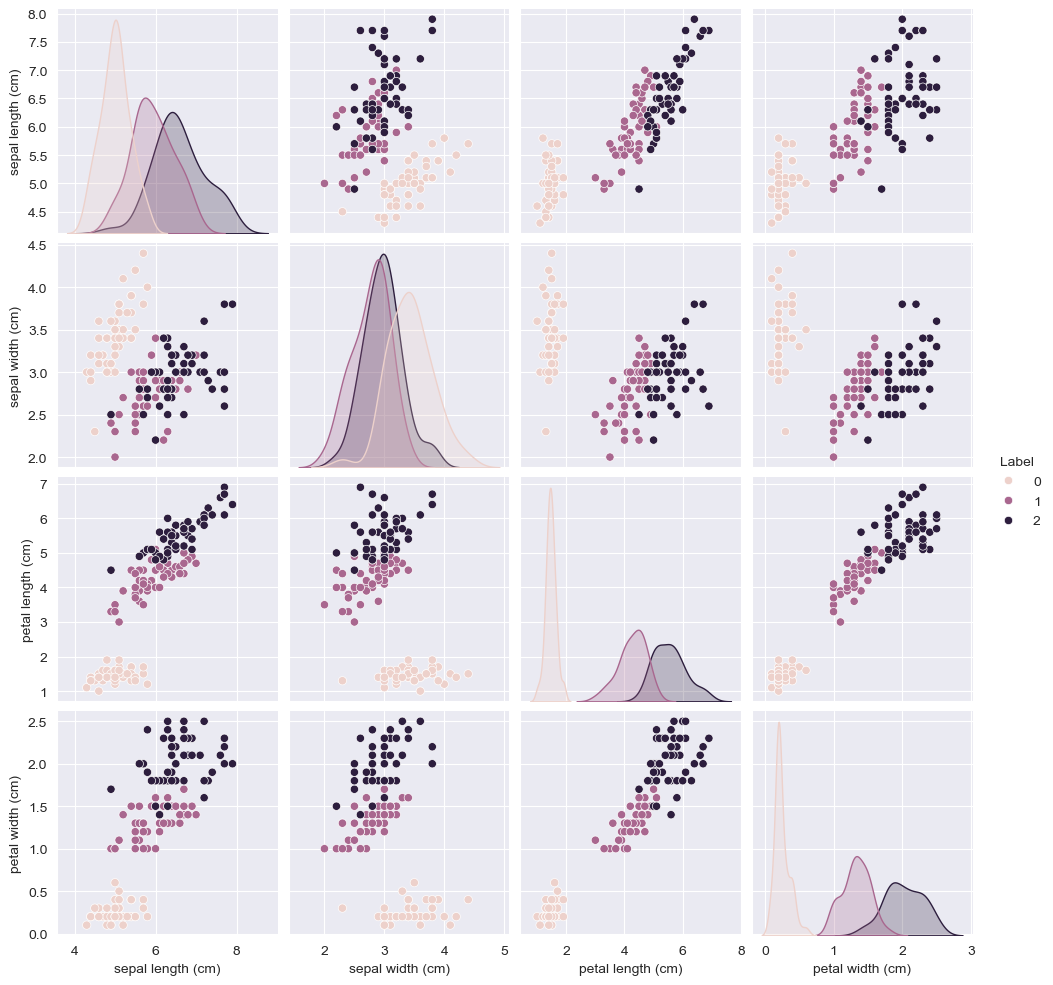

In [3]:
sns.pairplot(df,hue='Label')

### 规范化和编码数据

为了准备数据用于神经网络训练，我们需要将输入规范化到 [0..1] 的范围内。这可以通过简单的 `numpy` 操作完成，也可以使用 [Scikit Learn 方法](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.normalize.html)。

此外，你需要决定是否将目标标签进行独热编码（one-hot encoding）。PyTorch 和 TensorFlow 允许你以两种方式提供类别编号：可以是整数形式（从 0 到 N-1），也可以是独热编码向量。在创建神经网络结构时，你需要根据输入格式指定相应的损失函数（例如，数字表示使用 *sparse categorical crossentropy*，独热编码使用 *crossentropy loss*）。独热编码也可以通过 [Sklearn 实现](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)，或者使用以下代码片段：

```python
n_values = np.max(labels) + 1
labels_onehot = np.eye(n_values)[labels]
```


In [3]:
# Code to normalize and encode the data
#我要将训练集和数据集写到一起，并且在其中正则化
import torch.utils.data.dataset as dataset
import torch.utils.data.dataloader as dataloader
import torch
import numpy as np
import torchvision.transforms as transforms
#数据类型
# features = iris['data']
# labels = iris['target']
# class_names = iris['target_names']
# feature_names = iris['feature_names']
class FlowerDataset(dataset.Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
        self.max_value=np.max(features,axis=0)
        self.min_value=np.min(features,axis=0)

    def __len__(self):
        return len(self.features)
    def __getitem__(self, idx):
        feature = (self.features[idx]-self.min_value)/(self.max_value-self.min_value+1e-8)
        feature = torch.tensor(feature,dtype=torch.float32)
        return feature, self.labels[idx]



### 将数据分为训练集和测试集

由于我们没有单独的训练集和测试集，因此需要将数据拆分为训练集和测试集 [使用 Sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)


In [30]:

# Split the data
features_train, features_test, labels_train, labels_test = train_test_split(features,labels, test_size=0.2)

train_dataset=FlowerDataset(features_train,labels_train)
test_dataset=FlowerDataset(features_test,labels_test)

train_loader = dataloader.DataLoader(train_dataset, batch_size=32, shuffle=True)

test_loader = dataloader.DataLoader(test_dataset, batch_size=32, shuffle=False)



### 定义和训练神经网络

现在你已经准备好了，导入你喜欢的框架，定义神经网络并开始训练，同时观察训练和验证准确率的变化情况。


In [27]:
# Define the network
import torch.nn as nn
class FlowerNet(nn.Module):
    def __init__(self,hidden_size=10):
        super(FlowerNet, self).__init__()
        self.layers=nn.Sequential(
            nn.Linear(4,hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size,10),
            nn.ReLU(),
            nn.Linear(10,3)

        )

    def forward(self,x):
        for layer in self.layers:
            x=layer(x)
        return x

In [3]:
# Train the network
import matplotlib.pyplot as plt
def train(model,train_loader,loss_function=nn.CrossEntropyLoss(),epochs=200):
    optimizer=torch.optim.Adam(model.parameters(),lr=0.01)
    step=0
    fig,axs=plt.subplots(1,2)
    axs[0].set_title("Acc")
    axs[1].set_title("Loss")
    train_acc=[]
    train_loss=[]
    for epoch in range(epochs):
        for i, (batch__features, batch_labels) in enumerate(train_loader,1):
            predict=model(batch__features)
            loss=loss_function(predict,batch_labels.long())
            loss.backward()#反向传播
            optimizer.step()#优化
            optimizer.zero_grad()#清零梯度
            if(step%10==0):
                acc=(torch.argmax(predict,dim=1)==batch_labels).sum()/len(batch_labels)
                train_acc.append(acc)
                train_loss.append(loss.detach().numpy())
                print(f"Epoch: {epoch}, Step: {step}, Loss: {loss}, Acc: {acc}")
            step+=1
    axs[0].plot(train_acc)
    axs[1].plot(train_loss)
    plt.show()

def test(model,test_loader):
    for i,(test_feature,test_label) in enumerate(test_loader,1):
        predict = model(test_feature)
        acc=(torch.argmax(predict,dim=1)==test_label).sum()/len(test_label)
        print(f"Test Acc: {acc}")


Epoch: 0, Step: 0, Loss: 1.1022123098373413, Acc: 0.25
Epoch: 2, Step: 10, Loss: 1.0312494039535522, Acc: 0.5
Epoch: 5, Step: 20, Loss: 0.8696575164794922, Acc: 0.90625
Epoch: 7, Step: 30, Loss: 0.6755242347717285, Acc: 0.84375
Epoch: 10, Step: 40, Loss: 0.49962306022644043, Acc: 0.8125
Epoch: 12, Step: 50, Loss: 0.438920259475708, Acc: 0.96875
Epoch: 15, Step: 60, Loss: 0.3430841565132141, Acc: 0.96875
Epoch: 17, Step: 70, Loss: 0.28699713945388794, Acc: 1.0
Epoch: 20, Step: 80, Loss: 0.2439906895160675, Acc: 0.9375
Epoch: 22, Step: 90, Loss: 0.2613406479358673, Acc: 0.90625
Epoch: 25, Step: 100, Loss: 0.13023966550827026, Acc: 0.96875
Epoch: 27, Step: 110, Loss: 0.10003580898046494, Acc: 0.96875
Epoch: 30, Step: 120, Loss: 0.15471841394901276, Acc: 0.90625
Epoch: 32, Step: 130, Loss: 0.13176201283931732, Acc: 0.96875
Epoch: 35, Step: 140, Loss: 0.08090894669294357, Acc: 0.96875
Epoch: 37, Step: 150, Loss: 0.05762193351984024, Acc: 1.0
Epoch: 40, Step: 160, Loss: 0.03227236494421959, 

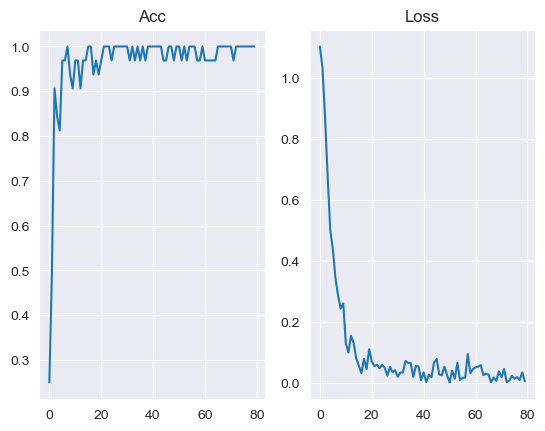

Test Acc: 0.9666666388511658


In [31]:
# Visualize train/validation accuracy graph
model=FlowerNet()
train(model,train_loader)
test(model,test_loader)

### 实验

现在你可以尝试不同的网络结构，看看它如何影响结果。试试以下几种方法：
1. 一个包含3个神经元（等于类别数）的单层网络
1. 一个包含小/中/大隐藏层的两层网络
1. 使用更多层的网络

当你使用包含大量神经元（参数）的复杂模型时，一定要注意观察过拟合现象。


Epoch: 0, Step: 0, Loss: 1.080731987953186, Acc: 0.375
Epoch: 2, Step: 10, Loss: 0.7726171612739563, Acc: 0.8125
Epoch: 5, Step: 20, Loss: 0.6864740252494812, Acc: 0.9375
Epoch: 7, Step: 30, Loss: 0.6938329935073853, Acc: 0.90625
Epoch: 10, Step: 40, Loss: 0.6289308667182922, Acc: 0.96875
Epoch: 12, Step: 50, Loss: 0.6286794543266296, Acc: 0.9375
Epoch: 15, Step: 60, Loss: 0.5974000692367554, Acc: 0.96875
Epoch: 17, Step: 70, Loss: 0.6194558143615723, Acc: 0.9375
Epoch: 20, Step: 80, Loss: 0.6201683282852173, Acc: 0.96875
Epoch: 22, Step: 90, Loss: 0.6027467846870422, Acc: 0.96875
Epoch: 25, Step: 100, Loss: 0.5803834199905396, Acc: 1.0
Epoch: 27, Step: 110, Loss: 0.6040763854980469, Acc: 0.96875
Epoch: 30, Step: 120, Loss: 0.5663850903511047, Acc: 1.0
Epoch: 32, Step: 130, Loss: 0.58546382188797, Acc: 1.0
Epoch: 35, Step: 140, Loss: 0.5718740224838257, Acc: 1.0
Epoch: 37, Step: 150, Loss: 0.588201105594635, Acc: 0.96875
Epoch: 40, Step: 160, Loss: 0.6032995581626892, Acc: 0.96875
Epoc

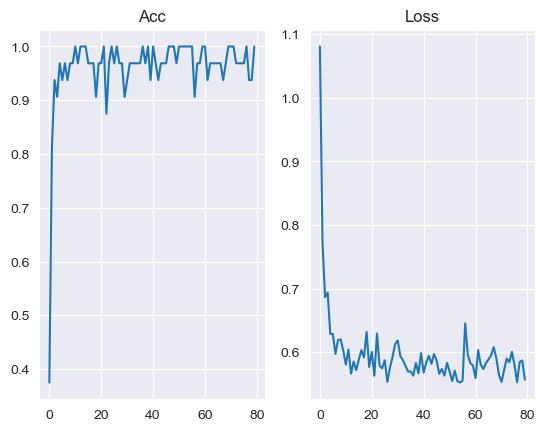

Test Acc: 0.9666666388511658


In [12]:
# Experiment
model=FlowerNet(hidden_size=200)
train(model,train_loader)
test(model,test_loader)

## 第2部分：MNIST训练

Keras和PyTorch都将MNIST作为内置数据集，因此你可以通过几行代码轻松获取它（[Keras](https://keras.io/api/datasets/mnist/)，[PyTorch](https://pytorch.org/vision/stable/datasets.html)）。你还可以直接加载训练集和测试集，而无需手动拆分它们。


Epoch: 0, Step: 0, Loss: 2.3015711307525635, Acc: 0.09375
Epoch: 0, Step: 10, Loss: 0.8189132213592529, Acc: 0.7109375
Epoch: 0, Step: 20, Loss: 0.5689046382904053, Acc: 0.828125
Epoch: 0, Step: 30, Loss: 0.29553332924842834, Acc: 0.8984375
Epoch: 0, Step: 40, Loss: 0.3941778242588043, Acc: 0.8984375
Epoch: 0, Step: 50, Loss: 0.37401413917541504, Acc: 0.921875
Epoch: 0, Step: 60, Loss: 0.18720585107803345, Acc: 0.9296875
Epoch: 0, Step: 70, Loss: 0.24141132831573486, Acc: 0.9375
Epoch: 0, Step: 80, Loss: 0.2711631655693054, Acc: 0.9375
Epoch: 0, Step: 90, Loss: 0.28698813915252686, Acc: 0.8984375
Epoch: 0, Step: 100, Loss: 0.18169109523296356, Acc: 0.953125
Epoch: 0, Step: 110, Loss: 0.198055237531662, Acc: 0.9375
Epoch: 0, Step: 120, Loss: 0.2717772126197815, Acc: 0.890625
Epoch: 0, Step: 130, Loss: 0.12001734972000122, Acc: 0.96875
Epoch: 0, Step: 140, Loss: 0.22107820212841034, Acc: 0.9296875
Epoch: 0, Step: 150, Loss: 0.11326264590024948, Acc: 0.9453125
Epoch: 0, Step: 160, Loss: 0

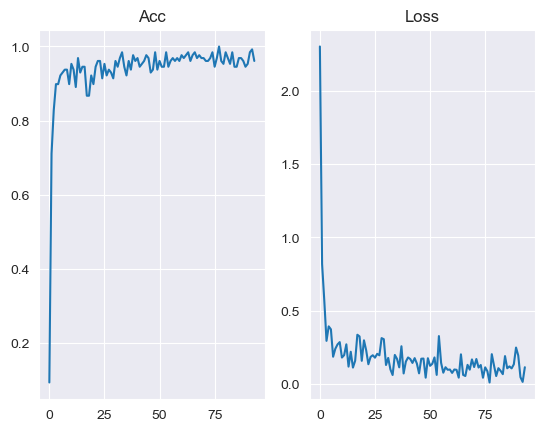

Test Acc: 0.967199981212616


In [6]:
# Load the dataset
import torchvision.datasets as dataset
import torchvision.transforms as transforms
import torch.utils.data.dataloader as dataloader
mnist_mean = 0.1307
mnist_std = 0.3081
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize([mnist_mean], [mnist_std])])
#不要轻易使用normalize，除非你知道你在干什么

train_dataset=dataset.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset=dataset.MNIST(root='./data', train=False, download=True, transform=transform)
import torch
train_loader=dataloader.DataLoader(train_dataset,batch_size=128, shuffle=True)
test_loader=dataloader.DataLoader(test_dataset,batch_size=64, shuffle=False)
import torch.nn as nn
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.layers=nn.Sequential(
            nn.Linear(28*28,256),
            nn.ReLU(),
            nn.Linear(256,10),

        )

    def forward(self,x):
        for layer in self.layers:
            x=layer(x)
        return x

Model = MNISTNet()

def train(model,train_loader,loss_function=nn.CrossEntropyLoss(),epochs=200):
    optimizer=torch.optim.Adam(model.parameters(),lr=0.007)
    step=0
    fig,axs=plt.subplots(1,2)
    axs[0].set_title("Acc")
    axs[1].set_title("Loss")
    train_acc=[]
    train_loss=[]
    for epoch in range(epochs):
        for i, (batch__features, batch_labels) in enumerate(train_loader,1):

            x=batch__features.view(-1,28*28)
            predict=model(x)

            loss=loss_function(predict,batch_labels.long())
            loss.backward()#反向传播
            optimizer.step()#优化
            optimizer.zero_grad()#清零梯度
            if(step%10==0):
                acc=(torch.argmax(predict,dim=1)==batch_labels).sum()/len(batch_labels)
                train_acc.append(acc)
                train_loss.append(loss.detach().numpy())
                print(f"Epoch: {epoch}, Step: {step}, Loss: {loss}, Acc: {acc}")
            step+=1
    axs[0].plot(train_acc)
    axs[1].plot(train_loss)
    plt.show()

train(Model,train_loader,epochs=2)

def test(model,test_loader):
    acc=0
    for i,(test_feature,test_label) in enumerate(test_loader,1):
        x=test_feature.view(-1,28*28)
        predict = model(x)
        acc+=(torch.argmax(predict,dim=1)==test_label).sum()
    acc=acc/len(test_loader.dataset)
    print(f"Test Acc: {acc}")
test(Model,test_loader)


现在，您需要执行上述步骤，以确保数据集已标准化（它可能已经标准化），并定义和训练一个神经网络。

## 重点

1. 神经网络可以用于传统的机器学习任务。然而，在许多情况下，它们过于强大，可能会导致过拟合。
1. 在本次作业中，观察过拟合现象并尝试避免它是非常重要的。
1. 使用像 Keras 这样的框架，有时训练神经网络相对简单。但您需要理解其中的原理。



---

**免责声明**：  
本文档使用AI翻译服务[Co-op Translator](https://github.com/Azure/co-op-translator)进行翻译。尽管我们努力确保翻译的准确性，但请注意，自动翻译可能包含错误或不准确之处。应以原始语言的文档作为权威来源。对于关键信息，建议使用专业人工翻译。我们对因使用本翻译而引起的任何误解或误读不承担责任。
